# 🚚 Floyd-Warshall — Roteirização de Entregas

**Problema simulado:** Uma pequena empresa de entregas tem um motoboy que precisa saber a **menor distância entre qualquer par de pontos** da cidade para planejar rotas eficientes.

Os pontos são:
- 🏭 Depósito (base)
- 🏪 Mercado
- 🏥 Farmácia
- 🏫 Escola
- 🏠 Casa do Cliente

> O grafo é **direcionado** (ruas de mão única) e **ponderado** (distância em km).

## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import copy

## 2. Definição do Grafo

Representamos as conexões como uma **matriz de adjacência**.
- `INF` = sem conexão direta entre os pontos
- Valores numéricos = distância em km

In [2]:
INF = float('inf')

# Nomes dos locais
lugares = ['Depósito', 'Mercado', 'Farmácia', 'Escola', 'Casa']
n = len(lugares)

# Matriz de adjacência (distâncias em km)
# Linha i -> Coluna j = distância de i para j
grafo = [
#  Dep  Merc  Farm  Esc  Casa
  [ 0,    2,   INF,   7,  INF],  # Depósito
  [INF,   0,    3,   INF,   5],  # Mercado
  [INF,  INF,   0,    1,  INF],  # Farmácia
  [INF,  INF,  INF,   0,    2],  # Escola
  [INF,  INF,  INF,  INF,   0],  # Casa
]

# Exibir o grafo original como tabela
def formata(val):
    return '∞' if val == INF else str(val)

df_original = pd.DataFrame(
    [[formata(v) for v in linha] for linha in grafo],
    index=lugares,
    columns=lugares
)
print("📋 Matriz de adjacência original (km):")
df_original

📋 Matriz de adjacência original (km):


,Depósito,Mercado,Farmácia,Escola,Casa
Depósito,0,2,∞,7,∞
Mercado,∞,0,3,∞,5
Farmácia,∞,∞,0,1,∞
Escola,∞,∞,∞,0,2
Casa,∞,∞,∞,∞,0


## 3. Visualização do Grafo

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127979 (\N{SCHOOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


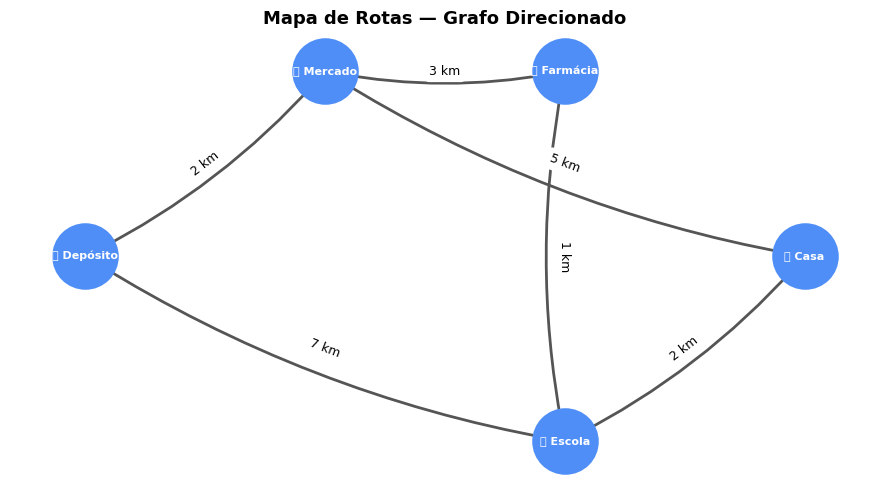

In [3]:
G = nx.DiGraph()
G.add_nodes_from(lugares)

for i in range(n):
    for j in range(n):
        if grafo[i][j] not in (0, INF):
            G.add_edge(lugares[i], lugares[j], weight=grafo[i][j])

pos = {
    'Depósito': (0, 1),
    'Mercado':  (1, 2),
    'Farmácia': (2, 2),
    'Escola':   (2, 0),
    'Casa':     (3, 1),
}

emojis = {
    'Depósito': '🏭 Depósito',
    'Mercado':  '🏪 Mercado',
    'Farmácia': '🏥 Farmácia',
    'Escola':   '🏫 Escola',
    'Casa':     '🏠 Casa',
}

labels = {n: emojis[n] for n in lugares}
edge_labels = nx.get_edge_attributes(G, 'weight')
edge_labels = {k: f"{v} km" for k, v in edge_labels.items()}

fig, ax = plt.subplots(figsize=(9, 5))
nx.draw_networkx_nodes(G, pos, node_color='#4f8ef7', node_size=2200, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#555', arrows=True,
                       arrowstyle='->', arrowsize=20, width=2,
                       connectionstyle='arc3,rad=0.1', ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, ax=ax)
ax.set_title('Mapa de Rotas — Grafo Direcionado', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Algoritmo Floyd-Warshall

A ideia central: para cada par `(i, j)`, verificamos se passar por um vértice intermediário `k` encurta o caminho:

```
dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])
```

Fazemos isso para **todos os k** possíveis.

In [4]:
def floyd_warshall(grafo):
    n = len(grafo)

    # Copia profunda para não alterar o grafo original
    dist = copy.deepcopy(grafo)

    # Matriz de predecessores (para reconstruir o caminho)
    pred = [[None]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j and dist[i][j] != INF:
                pred[i][j] = i  # o antecessor de j, vindo de i, é i

    # Triple loop — O(n³)
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
                    pred[i][j] = pred[k][j]  # atualiza predecessor

    return dist, pred


dist, pred = floyd_warshall(grafo)
print("✅ Floyd-Warshall executado com sucesso!")

✅ Floyd-Warshall executado com sucesso!


## 5. Resultado — Matriz de Distâncias Mínimas

In [5]:
df_resultado = pd.DataFrame(
    [[formata(v) for v in linha] for linha in dist],
    index=lugares,
    columns=lugares
)
print("📊 Menor distância entre todos os pares (km):")
df_resultado

📊 Menor distância entre todos os pares (km):


,Depósito,Mercado,Farmácia,Escola,Casa
Depósito,0,2,5,6,7
Mercado,∞,0,3,4,5
Farmácia,∞,∞,0,1,3
Escola,∞,∞,∞,0,2
Casa,∞,∞,∞,∞,0


## 6. Reconstrução do Caminho

In [6]:
def reconstruir_caminho(pred, origem, destino):
    """Retorna a lista de nós que formam o menor caminho de origem a destino."""
    if dist[origem][destino] == INF:
        return None

    caminho = []
    atual = destino
    while atual is not None:
        caminho.append(atual)
        if atual == origem:
            break
        atual = pred[origem][atual]

    caminho.reverse()
    return caminho


# Exemplos práticos de consulta
consultas = [
    (0, 4),  # Depósito → Casa
    (0, 3),  # Depósito → Escola
    (1, 4),  # Mercado  → Casa
]

print("🗺️  Menores rotas calculadas:\n")
for (o, d) in consultas:
    caminho = reconstruir_caminho(pred, o, d)
    nomes = ' → '.join([lugares[c] for c in caminho])
    km = dist[o][d]
    print(f"  {lugares[o]} ➜ {lugares[d]}: {nomes}  [{km} km]")

🗺️  Menores rotas calculadas:

  Depósito ➜ Casa: Depósito → Mercado → Casa  [7 km]
  Depósito ➜ Escola: Depósito → Mercado → Farmácia → Escola  [6 km]
  Mercado ➜ Casa: Mercado → Casa  [5 km]


## 7. Visualização da Melhor Rota: Depósito → Casa

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127979 (\N{SCHOOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


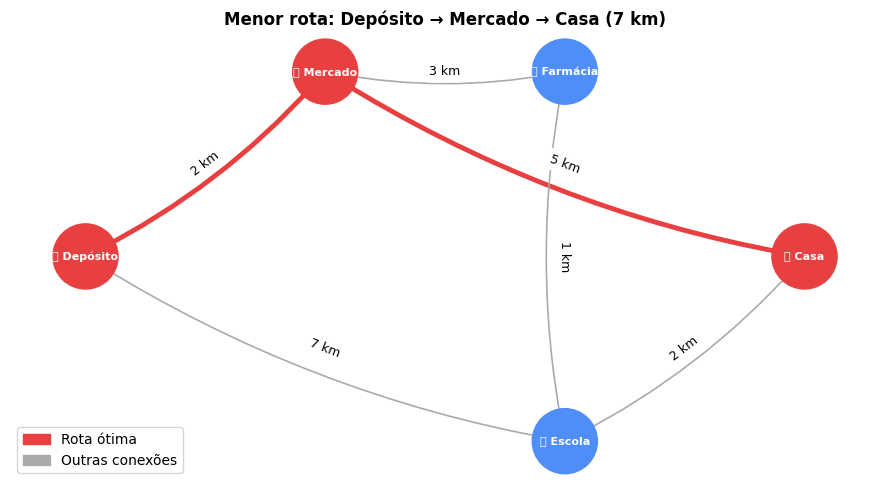

In [7]:
caminho_principal = reconstruir_caminho(pred, 0, 4)  # Depósito → Casa
arestas_rota = list(zip(caminho_principal[:-1], caminho_principal[1:]))
arestas_rota_nomes = [(lugares[u], lugares[v]) for u, v in arestas_rota]

cores_arestas = [
    '#e84040' if (u, v) in arestas_rota_nomes else '#aaaaaa'
    for u, v in G.edges()
]
larguras = [
    3.5 if (u, v) in arestas_rota_nomes else 1.2
    for u, v in G.edges()
]
cores_nos = [
    '#e84040' if i in caminho_principal else '#4f8ef7'
    for i in range(n)
]

fig, ax = plt.subplots(figsize=(9, 5))
nx.draw_networkx_nodes(G, pos, node_color=cores_nos, node_size=2200, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color=cores_arestas, width=larguras,
                       arrows=True, arrowstyle='->', arrowsize=20,
                       connectionstyle='arc3,rad=0.1', ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, ax=ax)

rota_str = ' → '.join([lugares[c] for c in caminho_principal])
ax.set_title(f'Menor rota: {rota_str} ({dist[0][4]} km)', fontsize=12, fontweight='bold')

patch_rota  = mpatches.Patch(color='#e84040', label='Rota ótima')
patch_resto = mpatches.Patch(color='#aaaaaa', label='Outras conexões')
ax.legend(handles=[patch_rota, patch_resto], loc='lower left')
ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Complexidade e Conclusão

| Aspecto | Detalhe |
|---|---|
| **Complexidade de tempo** | O(n³) |
| **Complexidade de espaço** | O(n²) |
| **Suporta pesos negativos?** | Sim (mas não ciclos negativos) |
| **Grafo direcionado?** | Sim |
| **Resultado** | Menor caminho entre **todos** os pares |

**Quando usar Floyd-Warshall no dia a dia:**
- Aplicativos de logística com múltiplas origens e destinos
- Redes de transporte público
- Jogos com mapas de nós (NPCs calculando rotas)
- Análise de redes sociais (distância entre usuários)